## Created by:
- Mikołaj Nowak 151813
- Igor Szymczak 160280

# General description
We've chosen Adult Income dataset, containing demographic and employment-related attributes of individuals from the 1994 U.S. Census database. \
The goal is to predict whether an individual earns more than 50K (currently it would be about 109K $) per year based on personal and professional features. \
Whole dataset available on kaggle: https://www.kaggle.com/datasets/mosapabdelghany/adult-income-prediction-dataset/data \
On kaggle there is also short description of each feature

In [247]:
import pandas as pd
import numpy as np
import dalex as dx
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings(action = 'ignore')

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Download latest version
df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "mosapabdelghany/adult-income-prediction-dataset", "adult.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


# Data preprocessing

We create target variable (placement aka whether student got a job after university) \
We also remove college ID as it is useless

In [3]:
df[['marital.status', 'occupation', 'relationship', 'income', 'workclass']] = df[['marital.status', 'occupation', 'relationship', 'income', 'workclass']].astype('category')
# We also can drop 'fnlwgt' as it is not relevant for our analysis
# We also drop "race", "sex", "native.country" as they are sensitive attributes
df.drop(columns=["race", "sex", "native.country", 'fnlwgt'], inplace=True)

In [4]:
# We can ignore 'education' as it is almost the same as 'education.num'
df.drop(columns=['education'], inplace=True)

In [5]:
df = df.rename(mapper = {'income' : 'income>50K'}, axis = 'columns')

In [6]:
# divide into X (normal variables) and y (target variable)
y = df['income>50K']
y = y.apply(lambda x : 0 if x == "<=50K" else 1).astype('category')
X = df.drop(columns="income>50K")

# EDA

## Plot 1
simple piechart showing proportion of people above and below 50K \
We see 24.1% of people earn more than 50K \
Data is a bit inbalanced, but not by huge amount, so we may leave it

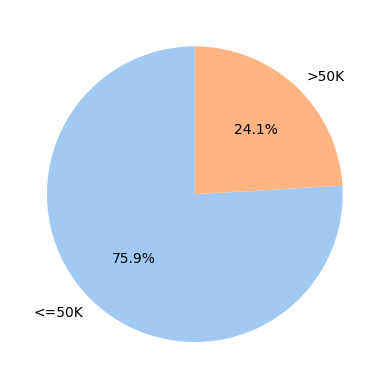

In [7]:
y_yes, y_no = y[y==1], y[y==0]
labels = ['<=50K', '>50K']
sizes = [len(y_no), len(y_yes)]

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors = sns.color_palette("pastel"))
plt.show()

## Plot 2
Below correlation matrix (it shows how much variables are correlated to each other) for numerical variables \
Each cell in the table shows the correlation between two variables.
- values close to 1 indicate that with first variable increase the second also increases
- values close to 0 indicates value of first variable does not influence on second (linearly at least)
- values close to -1 indicate that with first variable increase the second decreases
- Values on diagonal are always 1, as variable obviously determines itself

High values (positive or negative) means dependency and redundancy \
Luckily we see no correlations

<Axes: >

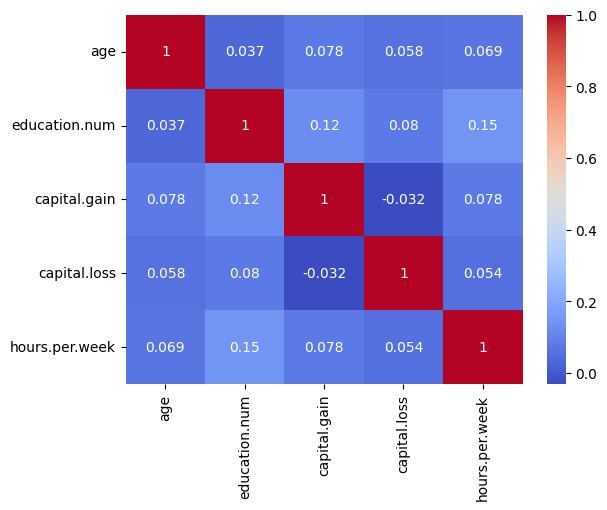

In [8]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

## Plot 3
dwe will show distribution of important features against target variable. \
first will be categorical (not numbers but some labels) variables\
We want to see whether some values influence target feature \
Be aware that vairables on histogram for numerical variables is stacked (so orange bars are amount of people earning >50k, and blue part without(!) orange part is amount of people earning <=50k)
We may see that:
- executive menagers (called exec-menagerial) and Proffesors (called Prof - speciality) are likely to earn more than 50k
- Married person (on plot with a civil, but also hold when married with soldier) are much more likely to earn more than 50k
- People from ages 40-54 are most likely to earn more than 50k compared to all ages, while ages 20-30 and 70+ are unlikely to earn much
- Higher educated people (represented numerically by education.num) are much more likely to earn more than 50k

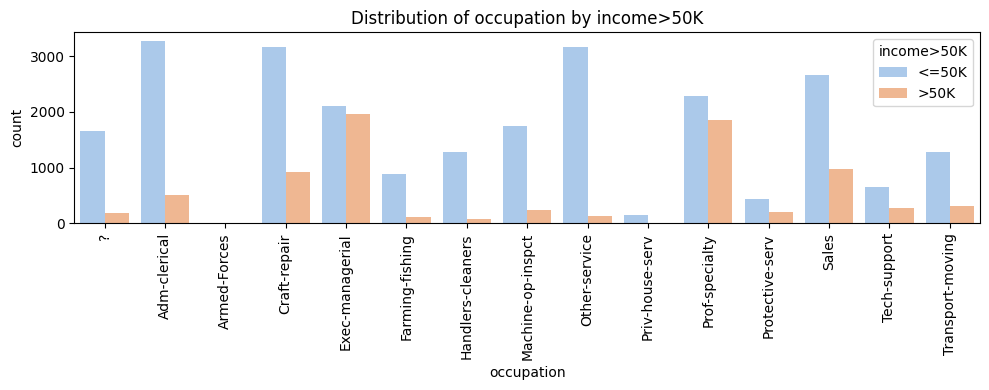

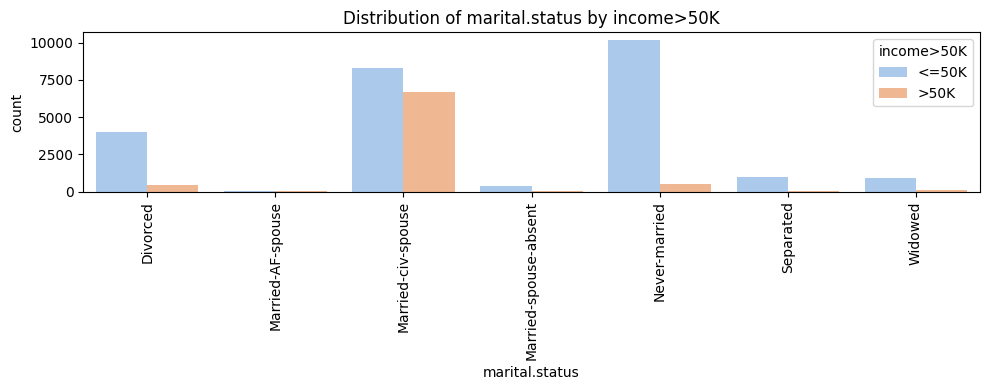

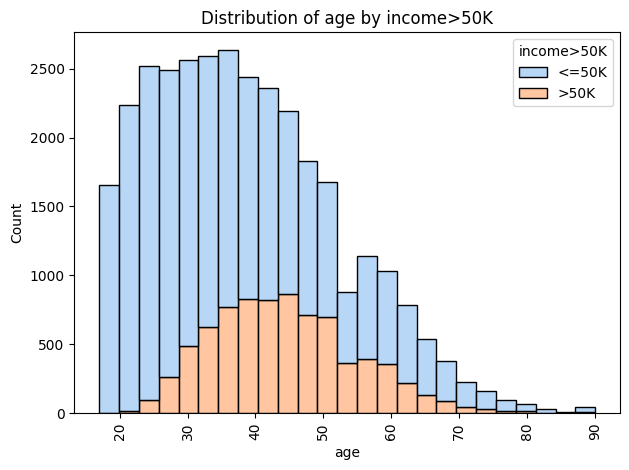

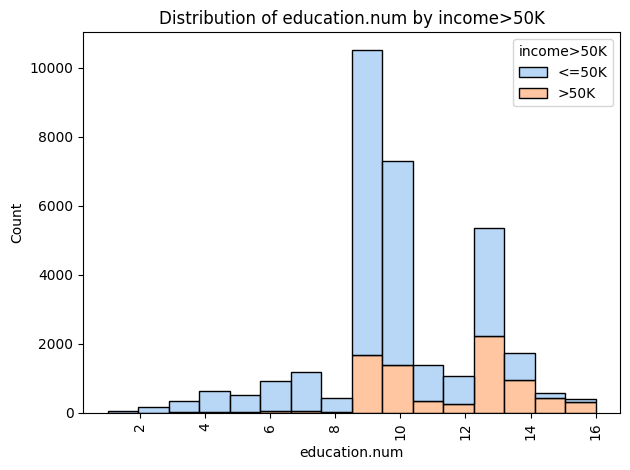

In [213]:
cat_cols = ['occupation', 'marital.status']
num_cols = ['age', 'education.num']
for col in cat_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, hue=y.name, palette='pastel')
    plt.title('Distribution of {col} by {y}'.format(col=col, y=y.name))
    plt.xticks(rotation=90)
    plt.legend(title=y.name, loc='upper right')
    plt.tight_layout()
    plt.show()
for col in num_cols:
    #plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, hue=y.name, palette='pastel', multiple="stack",
                 bins = min(25, X[col].nunique()))
    plt.title('Distribution of {col} by {y}'.format(col=col, y=y.name))
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

## Plot 4
See influence of having any capital.gain or capital.loss on income \
We can see that having either gain of loss of capital increases chances of earning more than 50k (probably because most people not earning much don't play on stock market or gather other assets)

<Axes: xlabel='has_capital', ylabel='count'>

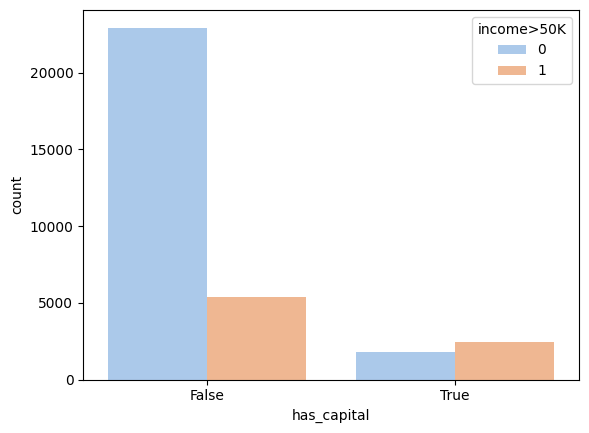

In [207]:
X_plot_4 = X.copy()
X_plot_4['has_capital'] = ((X['capital.gain'] > 0) | (X['capital.loss'] > 0))
sns.countplot(data=X_plot_4, x='has_capital', hue=y.loc[X_plot_4.index], palette='pastel')

In [245]:
intresting_occupations = ['Other-service', 'Prof-specialty', 'Sales', 'Tech-support', 'Craft-repair', 'Adm-clerical']
X_plot_5 = X.copy().loc[X['occupation'].isin(intresting_occupations)]
X_plot_5['occupation'] = X_plot_5['occupation'].cat.remove_unused_categories()

## Plot 5
Violinplot of occupation and age vs income; \
For each of chosen occupations it creates a plot; width determines how many of people of that age are \
It contains 2 differently colored parts, representing different income groups \
It only show distributions of those 2 income groups, not numerical comparison (as people with income<=50k are about 76% of whole dataset)
We may see that:
- In all jobs higher-paid positions have average older age
- It is especially visible in Sales and Tech-support

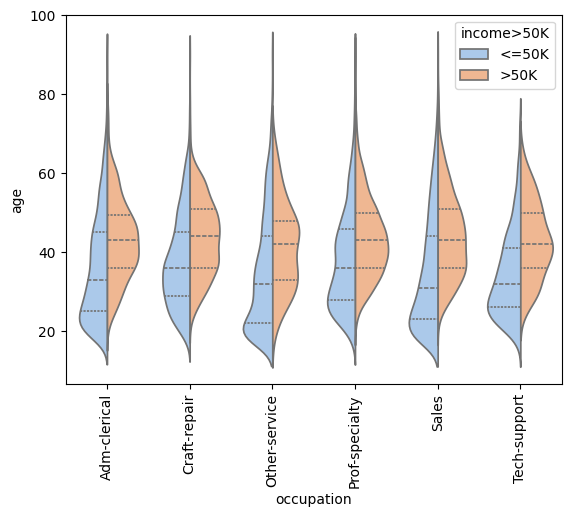

In [246]:
sns.violinplot(data = X_plot_5, x='occupation', y='age', hue = df['income>50K'], palette='pastel', split=True, inner="quart")
plt.xticks(rotation=90)
plt.legend(title=y.name, loc='upper right')
plt.show()

# Pipeline And Model creation

In [ ]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [15]:
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns
categorical_cols =  X.select_dtypes(include=['category']).columns
preprocessor = ColumnTransformer(transformers=[
    ('numerical', StandardScaler(), numerical_cols),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

pipe = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', XGBRegressor())
])
pipe

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  Index(['age', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['workclass', 'marital.status', 'occupation', 'relationship'], dtype='object'))])),
                ('model',
                 XGBRegressor(...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [ ]:
#use if you want to train model; not for explainability
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
pipe.fit(X_train, y_train)
result = pipe.predict(X_test) > 0.5
np.sum(result ==y_test.values.T) / y_test.shape[0]

0.8692803767018119

In [17]:
pipe.fit(X, y)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  Index(['age', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['workclass', 'marital.status', 'occupation', 'relationship'], dtype='object'))])),
                ('model',
                 XGBRegressor(...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

## Pipeline with hyperparameter tuning

In [ ]:
#takes a few seconds, so we comment it out

# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# param_grid = dict(
#     model__n_estimators=[100, 200, 300],
#     model__learning_rate=[0.05, 0.1, 0.2, 0.3],
#     model__max_depth = [4,6,8]
# )
# # perform gridsearch
# grid_search = GridSearchCV(pipe, param_grid=param_grid, verbose=0)
# grid_search.fit(X_train, y_train)
# print(grid_search.best_estimator_)

In [19]:
# result = grid_search.predict(X) > 0.5
# result = result.astype('int32')

In [20]:
# np.sum(result ==y.values.T) / y.shape[0]

# Report on Explanability

In [21]:
exp = dx.Explainer(pipe, X, y, verbose=False)

In [22]:
fi = exp.model_parts()

In [ ]:
var_splits={col : sorted(list(X[col].unique())) for col in X.columns}

# Plot 1
It shows importance of some features in predicting whether income is higher than 50k \
The bigger the number the bigger influence of that feature on prediction \
We can see that marital.status, capital.gain, age and education.num are most important features, which confirms relationships from plot 3 and plot 4


In [23]:
fi.plot()

# Plot 2
It shows average prediction for each value of given feature \
e.g. if value at education.num == 14 is 0.35, it means model average prediction for this education.num is 14
Average prediction means how often model predicted that person earns more than 50k on scale 0 - Never to 1 - Always. If result is bigger than 0.5, model will classify person as earning more than 50K 
* it technically go above 1 or below 0, yet it is very unlikely; if it is the case,  treat this as model 1 and 0 respectively 

We can see that:
- Education.num prediction average goes steadily up with increase of it's value
- capital.gain and capital.loss highly oscilates (probably because little amount of data with such values is provided)

In [248]:
exp.model_profile(variable_splits=var_splits).plot(facet_scales= "free_x")
exp.model_profile(variable_type='categorical',
                  variables = ['marital.status', 'occupation', 'relationship']).plot(facet_ncol=1)

Calculating ceteris paribus: 100%|██████████| 9/9 [00:00<00:00, 40.19it/s]


Calculating ceteris paribus: 100%|██████████| 3/3 [00:00<00:00, 59.33it/s]


## Plot 3
ceteris paribus profiles: what would be model predictions if we change value of 1 feature, but keeping all others the same. \
Can be helpful to see how specific feature value influences the score \
If you want to check some value, write it's index square brackets after "indices" (for multiple ones separate them by comma)

In [249]:
indices = [15]  # You can change these index or add more indices
cat_variables = X.select_dtypes(include=['category']).columns.values
exp.predict_profile(X.iloc[indices], variable_splits=var_splits).plot()
for var in cat_variables:
    exp.predict_profile(X.iloc[indices], variables = var).plot()

Calculating ceteris paribus: 100%|██████████| 9/9 [00:00<00:00, 127.26it/s]


Calculating ceteris paribus: 100%|██████████| 1/1 [00:00<00:00, 119.06it/s]


Calculating ceteris paribus: 100%|██████████| 1/1 [00:00<00:00, 177.27it/s]


Calculating ceteris paribus: 100%|██████████| 1/1 [00:00<00:00, 124.54it/s]


Calculating ceteris paribus: 100%|██████████| 1/1 [00:00<00:00, 166.46it/s]


## Plot 4
So called shapley values; Allows to see prediction of income of a person (0 aka <=50K or 1 aka >50K) And how each attribute contributed to a prediction \
You can change number of index variable to get different's person breakdown \

In [30]:
index = 15
exp.predict_parts(X.iloc[index], type='shap', N = 2000).plot(
    title = "Shapley values for observation 15 with prediction {v}".format(v = int(exp.predict(X.iloc[[index]]) > 0.5)))

# Most representative examples of each class

In [163]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
X_transformed = pd.DataFrame(pipe.named_steps['preprocessing'].transform(X).todense())
class_yes = X_transformed[y.values == 1]
class_no = X_transformed[y.values == 0]
clustered_yes = KMeans(n_clusters=3).fit(class_yes)
clustered_no = KMeans(n_clusters=3).fit(class_no)

In [164]:
closest, _ = pairwise_distances_argmin_min(clustered_yes.cluster_centers_, class_yes)
closest = class_yes.index[closest]
closest_yes = X.iloc[closest]
closest, _ = pairwise_distances_argmin_min(clustered_yes.cluster_centers_, class_no)
closest = class_no.index[closest]
closest_no = X.iloc[closest]

Below 3 most representative examples for income > 50k

In [165]:
closest_yes

,age,workclass,education.num,marital.status,occupation,relationship,capital.gain,capital.loss,hours.per.week
3687,43,Private,11,Married-civ-spouse,Exec-managerial,Husband,3103,0,48
1522,52,Private,13,Married-civ-spouse,Exec-managerial,Husband,99999,0,50
425,45,Private,11,Married-civ-spouse,Exec-managerial,Husband,0,1977,50


Below 3 most representative examples for income <=50k

In [166]:
closest_no

,age,workclass,education.num,marital.status,occupation,relationship,capital.gain,capital.loss,hours.per.week
13520,48,Private,12,Married-civ-spouse,Prof-specialty,Husband,0,0,45
1679,63,Self-emp-not-inc,14,Married-civ-spouse,Farming-fishing,Husband,41310,0,50
1055,37,Private,12,Married-civ-spouse,Prof-specialty,Husband,0,1740,45


To be able to plot them, we will reduce dimensionality using PCA (tries to compress all data features into 2 here to be able to plot it on a grid)

In [167]:
from sklearn.decomposition import PCA
import umap

transformer = PCA(n_components=2)
transformed_data = transformer.fit_transform(X_transformed)
feature_names = [f"feature_{i+1}" for i in range(transformed_data.shape[1])]
transformed_data = pd.DataFrame(transformed_data, columns=feature_names)
transformed_data["target"] = y

<Axes: xlabel='feature_1', ylabel='feature_2'>

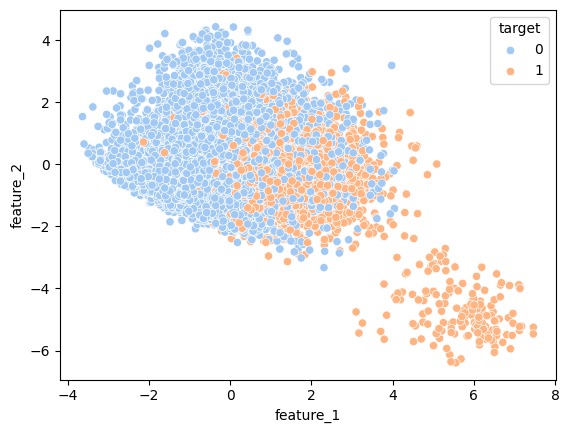

In [168]:
sns.scatterplot(data=transformed_data, x="feature_1", y="feature_2", hue="target", palette='pastel')

Below a plot Of most common representatives in PCA reduction

<Axes: xlabel='feature_1', ylabel='feature_2'>

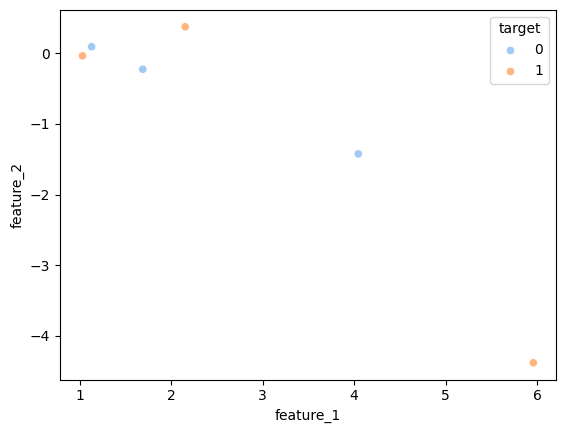

In [174]:
indices = list(closest_yes.index.values) + list(closest_no.index.values)
sns.scatterplot(data=transformed_data.iloc[indices], x="feature_1", y="feature_2", hue="target", palette='pastel')